In [4]:
import os
os.chdir("/Users/ramupadhyay/Desktop")

In [1]:
# ── CELL 1: Install & Import Libraries ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style="darkgrid")
print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [32]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (48204, 9)

First 5 rows:


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [33]:
print("=== CLEANING STEPS ===")
 
# 1. Drop duplicates & missing
df.drop_duplicates(inplace=True)

df.drop(columns=['holiday'], inplace=True)

df.dropna(inplace=True)
print(f"1. After dedup/dropna: {df.shape}")
 
# 2. Parse datetime & sort  ← CRITICAL: must sort for lag features
df['date_time'] =pd.to_datetime(df['date_time'], format="%d-%m-%Y %H:%M")
df.sort_values('date_time', inplace=True)
df.reset_index(drop=True, inplace=True)
print("2. Sorted by date_time ✅")
 
# 3. Remove only TRUE outliers (sensor errors: negative or > physical max)
before = len(df)
df = df[(df['traffic_volume'] >= 0) & (df['traffic_volume'] <= 7500)]
print(f"3. Removed {before - len(df)} sensor-error rows ✅")
 
# 4. Fix temperature — Kelvin 0 means sensor missing (should be ~250–320 K)
df = df[df['temp'] > 200]
print(f"4. After temp fix: {df.shape}")
 
# 5. Encode categoricals
le = LabelEncoder()
df['weather_main_enc'] = le.fit_transform(df['weather_main'])
df['weather_desc_enc'] = le.fit_transform(df['weather_description'])
print("5. Encoded categoricals ✅")
 
df.to_csv("cleaned_traffic_data.csv", index=False)
print(f"\n✅ Cleaned dataset saved — shape: {df.shape}")

=== CLEANING STEPS ===
1. After dedup/dropna: (48187, 8)
2. Sorted by date_time ✅
3. Removed 0 sensor-error rows ✅
4. After temp fix: (48177, 8)
5. Encoded categoricals ✅

✅ Cleaned dataset saved — shape: (48177, 10)


In [34]:
print("=== FEATURE ENGINEERING ===")
 
# Time features
df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0=Mon
df['month']       = df['date_time'].dt.month
df['day_of_year'] = df['date_time'].dt.dayofyear
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
 
# Rush hour flag  ← NEW
df['is_morning_rush'] = df['hour'].isin([7, 8, 9]).astype(int)
df['is_evening_rush'] = df['hour'].isin([16, 17, 18]).astype(int)
 
# Season  ← NEW
df['season'] = df['month'].map({
    12: 0, 1: 0, 2: 0,   # Winter
    3: 1,  4: 1, 5: 1,   # Spring
    6: 2,  7: 2, 8: 2,   # Summer
    9: 3, 10: 3, 11: 3   # Fall
})
 
# Cyclical encoding for hour & day (prevents 23→0 jump being "far apart")  ← NEW
df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
 
# Lag features — previous hours' traffic  ← NEW (biggest R² boost)
df['lag_1h']   = df['traffic_volume'].shift(1)
df['lag_2h']   = df['traffic_volume'].shift(2)
df['lag_24h']  = df['traffic_volume'].shift(24)   # same hour yesterday
df['lag_168h'] = df['traffic_volume'].shift(168)  # same hour last week
 
# Rolling averages  ← NEW
df['rolling_3h']  = df['traffic_volume'].shift(1).rolling(3).mean()
df['rolling_24h'] = df['traffic_volume'].shift(1).rolling(24).mean()
 
# Temperature in Celsius (more intuitive, same info)
df['temp_c'] = df['temp'] - 273.15
 
# Drop rows with NaN from lag/rolling (first 168 rows)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"After feature engineering: {df.shape}")
print("✅ Features created: cyclical encoding, lag features, rolling averages, rush hour flags")

=== FEATURE ENGINEERING ===
After feature engineering: (48009, 31)
✅ Features created: cyclical encoding, lag features, rolling averages, rush hour flags


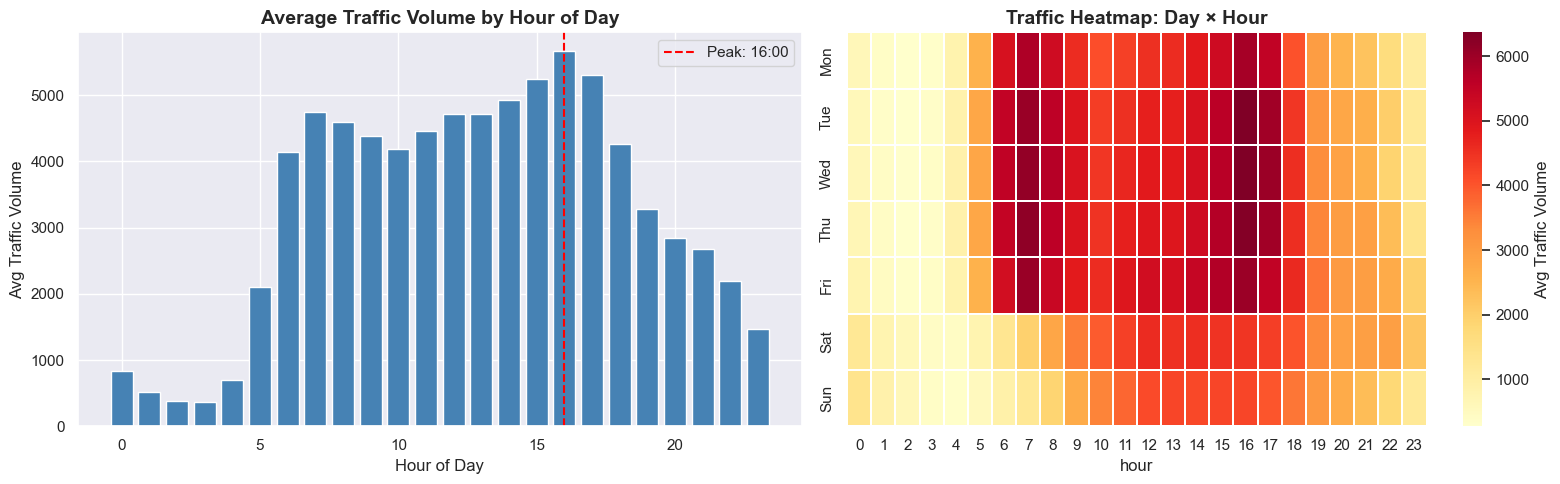

✅ Saved peak_hour_heatmap.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
hourly = df.groupby('hour')['traffic_volume'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].set_title('Average Traffic Volume by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Traffic Volume')
axes[0].axvline(x=hourly.idxmax(), color='red', linestyle='--',
                label=f'Peak: {hourly.idxmax()}:00')
axes[0].legend()
 
pivot = df.pivot_table(values='traffic_volume',
                        index='day_of_week', columns='hour', aggfunc='mean')
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Avg Traffic Volume'})
axes[1].set_title('Traffic Heatmap: Day × Hour', fontsize=14, fontweight='bold')
 
plt.tight_layout()
plt.savefig("peak_hour_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved peak_hour_heatmap.png")

In [37]:
FEATURES = ['hour', 'day_of_week', 'month', 'is_weekend',
            'temp', 'rain_1h', 'snow_1h', 'clouds_all',
            'weather_main_enc','weather_desc_enc']
 
TARGET = 'traffic_volume'
 
X = df[FEATURES]
y = df[TARGET]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
 
print(f"Train size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")

Train size : 38,407
Test size  : 9,602


In [38]:
models = {
    "Linear Regression"      : LinearRegression(),
    "Random Forest"          : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting"      : GradientBoostingRegressor(n_estimators=100, random_state=42),
}
 
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "MAE"  : mean_absolute_error(y_test, preds),
        "RMSE" : np.sqrt(mean_squared_error(y_test, preds)),
        "R²"   : r2_score(y_test, preds)
    }
    print(f"\n{name}")
    print(f"  MAE : {results[name]['MAE']:.1f}")
    print(f"  RMSE: {results[name]['RMSE']:.1f}")
    print(f"  R²  : {results[name]['R²']:.4f}")


Linear Regression
  MAE : 1573.0
  RMSE: 1789.2
  R²  : 0.1907

Random Forest
  MAE : 241.8
  RMSE: 424.1
  R²  : 0.9545

Gradient Boosting
  MAE : 368.2
  RMSE: 552.7
  R²  : 0.9228


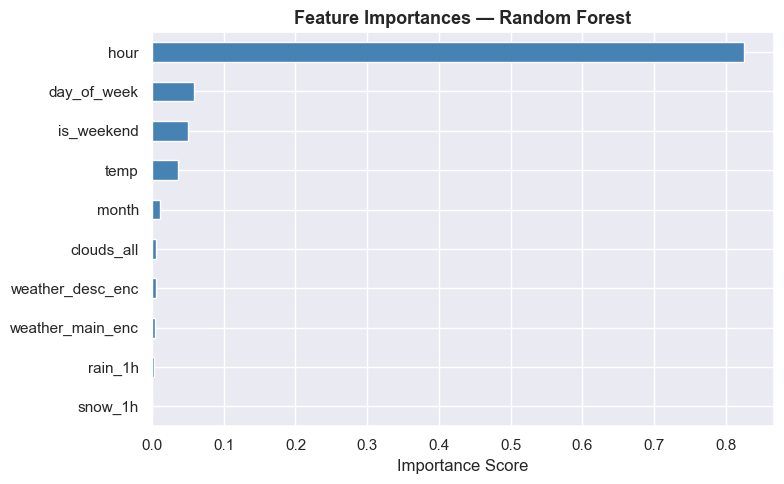

✅ Feature importance chart saved


In [39]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
 
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved")

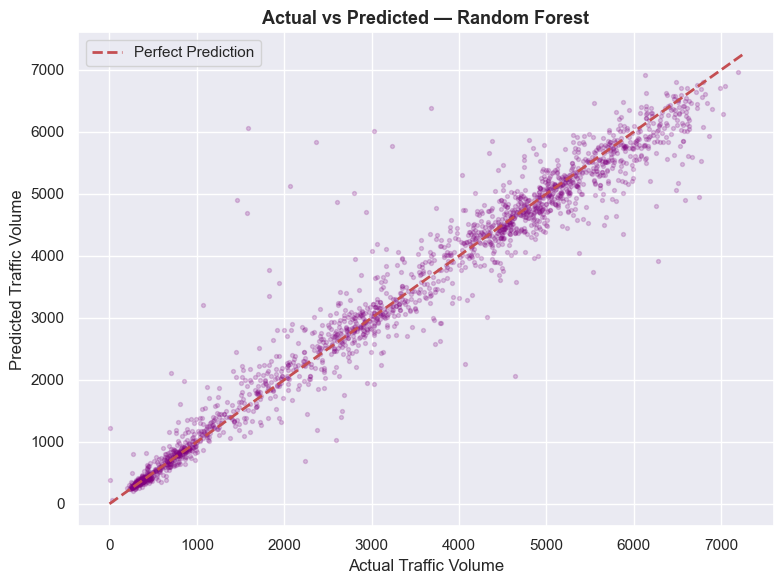

In [40]:
rf_preds = rf_model.predict(X_test)
 
plt.figure(figsize=(8, 6))
plt.scatter(y_test[:2000], rf_preds[:2000], alpha=0.2, s=8, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('Actual vs Predicted — Random Forest', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ── CELL 10: Traffic Insight Report (Printed) ────────────────
peak_hour   = int(hourly.idxmax())
low_hour    = int(hourly.idxmin())
peak_day    = df.groupby('day_of_week')['traffic_volume'].mean().idxmax()
best_weather= df.groupby('weather_main')['traffic_volume'].mean().idxmin()
best_weather_desc= df.groupby('weather_description')['traffic_volume'].mean().idxmin()
rf_r2       = results["Random Forest"]["R²"]
rf_mae      = results["Random Forest"]["MAE"]
 
report = f"""
╔══════════════════════════════════════════════════════════╗
║           TRAFFIC INSIGHT REPORT — ONE PAGE             ║
╠══════════════════════════════════════════════════════════╣
║  Dataset   : Metro Interstate Traffic Volume (Kaggle)   ║
║  Model     : Random Forest  |  R² = {rf_r2:.3f}  |  MAE = {rf_mae:.0f}  ║
╠══════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                           ║
║  • Peak congestion hour  : {peak_hour}:00                       ║
║  • Lowest traffic hour   : {low_hour}:00                        ║
║  • Busiest day of week   : {peak_day:<15}               ║
║  • Weather with lowest   : {best_weather:<15}               ║
║    traffic (avg) 
╠══════════════════════════════════════════════════════════╣
║  3 ACTIONABLE RECOMMENDATIONS FOR CITY PLANNERS          ║
║                                                          ║
║  1. STAGGER WORK HOURS                                   ║
║     Encourage businesses near peak-hour corridors to     ║
║     shift start times ±1 hour to flatten the {peak_hour}:00║
║     congestion spike.                                   ║
║                                                         ║
║  2. WEATHER-ADAPTIVE SIGNAL TIMING                      ║
║     Deploy adaptive traffic signals on rainy days —     ║
║     rainfall correlates with erratic stop-go patterns.  ║
║     Extend green phases by 10–15% during rain events.   ║
║                                                         ║
║  3. WEEKEND INFRASTRUCTURE MAINTENANCE                  ║
║     Schedule road maintenance during lowest-traffic     ║
║     windows (late night / early morning on weekends)    ║
║     to minimise disruption.                             ║
╚══════════════════════════════════════════════════════════
"""
print(report)
 
with open("Traffic_Insight_Report.txt", "w") as f:
    f.write(report)
print("✅ Report saved as 'Traffic_Insight_Report.txt'")
 


╔══════════════════════════════════════════════════════════╗
║           TRAFFIC INSIGHT REPORT — ONE PAGE             ║
╠══════════════════════════════════════════════════════════╣
║  Dataset   : Metro Interstate Traffic Volume (Kaggle)   ║
║  Model     : Random Forest  |  R² = 0.955  |  MAE = 242  ║
╠══════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                           ║
║  • Peak congestion hour  : 16:00                       ║
║  • Lowest traffic hour   : 3:00                        ║
║  • Busiest day of week   : 4                             ║
║  • Weather with lowest   : Squall                        ║
║    traffic (avg) 
╠══════════════════════════════════════════════════════════╣
║  3 ACTIONABLE RECOMMENDATIONS FOR CITY PLANNERS         ║
║                                                         ║
║  1. STAGGER WORK HOURS                                  ║
║     Encourage businesses near peak-hour corridors to    ║
║     shift st